# Traitement de l'EUEMr
Ce Notebook qui permet générer le réseau baysien basé sur les données de l'EUEMr

## Table des matières
- [Formatage de l'EUEMr](#PreTraitement)
- [Création du BN](#Creation)
- [Test](#Test)

In [2]:
"""
Created on 26-06-2025

@author: cv1751 - Brice Le Lostec
@description: Class for generating Bayesian Networks (BN) using pyAgrum.
@note: This class provides methods to save, load, plot Bayesian Networks and load CSV files.
@version: 1.0
python 3.11

"""
import numpy as np
import pandas as pd
import sys
import os
import yaml

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from utils.Master_genereBN import Master_genereBN
from EUEMr import FormatageEUEMr, EUEMr

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

# PreTraitement
Creer un fichier csv formaté avec les colonnes d'intérêt de l'EUEMr, lesquelles sont transformées

In [2]:
# Creer un fichier csv formaté avec les colonnes d'intérêt
InsClsSondage = FormatageEUEMr()
InsClsSondage.Main()
#InsClsSondage.get_Mettadata()


DataFrame saved to n:\Mes Documents\Projets LTE\Projet archQc\code\GITHUB_Repo\LTE-Sampler-Residential//data//EUEMr//2022//sondage_residentiel_version_finale_formatted.csv.


# Création
Création d'un réseau bayesien

In [3]:
import pyAgrum as gum
gum.availableBNExts()

'bif|dsl|net|bifxml|o3prm|uai|xdsl'

In [3]:
#import pyAgrum
#gum.availableBNExts()

InsClsEUEMr = EUEMr()
InsClsEUEMr.Make_csv()
InsClsEUEMr.Make_BN()

path = "../data/BayesianNetwork/BN_EUEMr.XDSL"
InsClsEUEMr.Save_BN(path)

#save Structure

with open("../dataStructure/Bn.yml", 'w') as outfile:
    yaml.dump([InsClsEUEMr.NOEUD_EUEMr, InsClsEUEMr.LIST_Dict], outfile, default_flow_style=False)




In [14]:
with open("../dataStructure/Bn.yml", 'r') as file:
        a,b = yaml.safe_load(file)
b

{'An_Construction': {'0': '< 1950',
  '1': '[1950 - 1960)',
  '2': '[1960 - 1970)',
  '3': '[1970 - 1980)',
  '4': '[1980 - 1990)',
  '5': '[1990 - 2000)',
  '6': '[2000 - 2010)',
  '7': '[2010 - 2020)',
  '8': '>= 2020'},
 'Mode_Occupation': {'0': 'Locataire', '1': 'Proprietaire'},
 'Nombre_Etages': {'0': 'Un étage',
  '1': 'Deux étages',
  '2': 'Trois étages et plus'},
 'Nombre_Personnes': {'0': '1',
  '1': '2',
  '2': '3',
  '3': '4',
  '4': '5 et plus'},
 'Nombre_Pieces': {'0': '1',
  '1': '2',
  '10': '11',
  '11': '12',
  '12': '13',
  '13': '14',
  '14': '15 et plus',
  '2': '3',
  '3': '4',
  '4': '5',
  '5': '6',
  '6': '7',
  '7': '8',
  '8': '9',
  '9': '10'},
 'Presence_Garage': {'0': 'Pas de Garage',
  '1': 'Garage non chauffé',
  '2': 'Garage chauffé à électricité',
  '3': 'Garage chauffé à autre source'},
 'Presence_SousSol': {'0': 'Sous sol 6 pied',
  '1': 'Vide sanitaire moins 6 pieds',
  '2': 'Aucun Sous-sol ou vide sanitaire',
  '3': 'Sous-sol et vide sanitaire'},
 '

# Test
Test du réseau bayesien créé

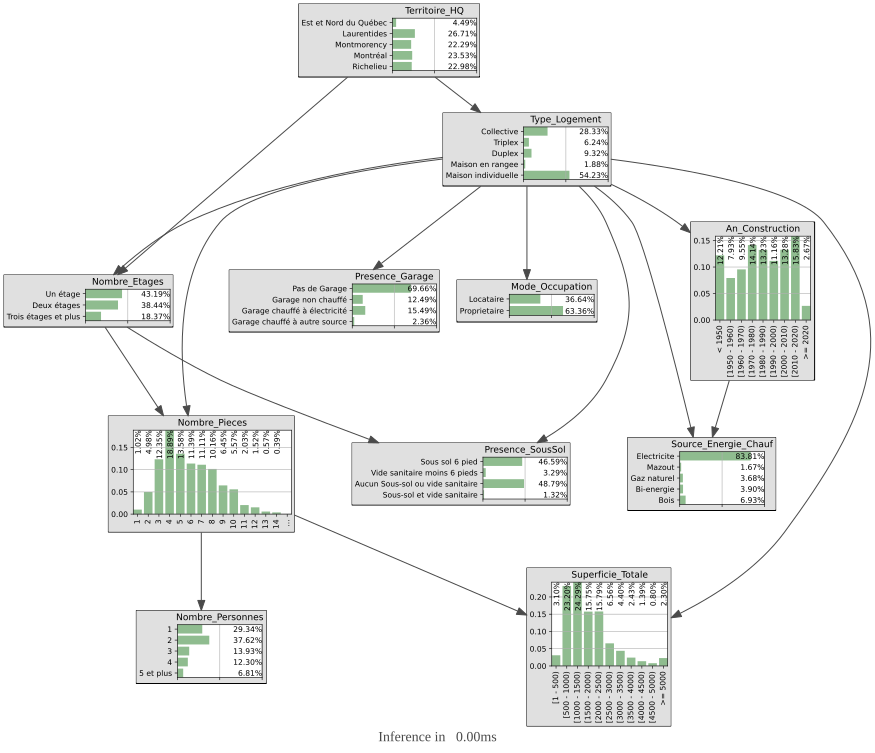

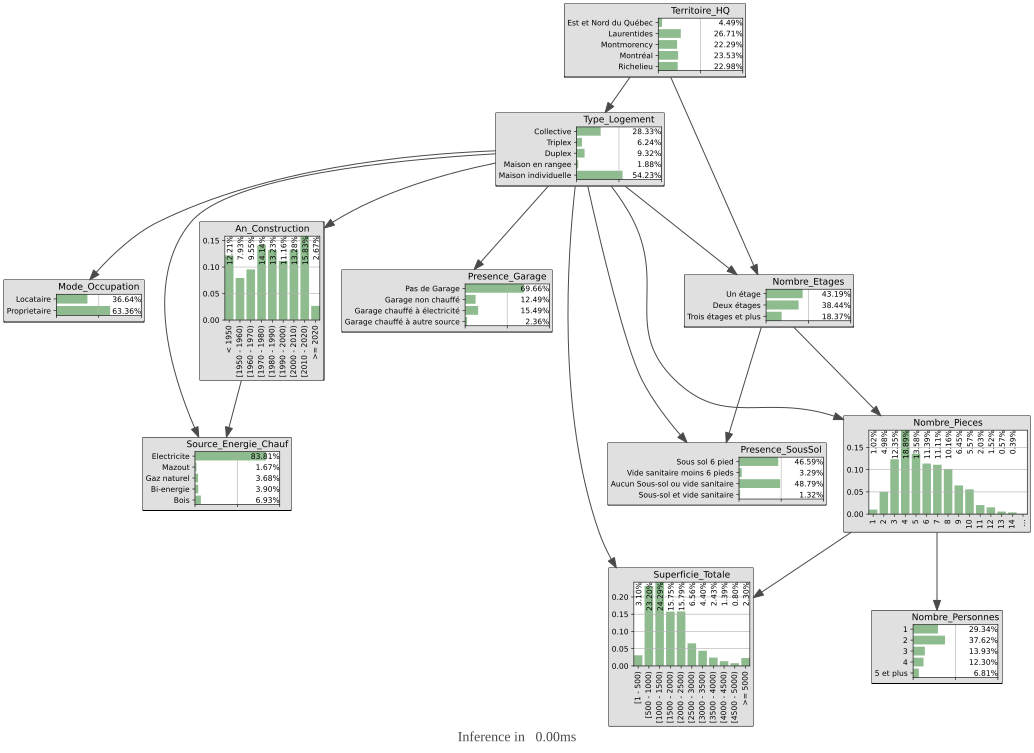

In [7]:
import pyAgrum as gum
#import pyAgrum.lib.ipython as gnb
import pyAgrum.lib.notebook as gnb

# Load the Bayesian Network from the saved file
InsClsEUEMr_2 = EUEMr()
path = parent_dir+"/data/BayesianNetwork/BN_EUEMr.XDSL"
InsClsEUEMr_2.Load_BN(path)

# Display the Bayesian Network - Avant enregistrement
gnb.showInference(InsClsEUEMr.bn,evs={},size = '30')

# Display the Bayesian Network - Apres enregistrement
gnb.showInference(InsClsEUEMr_2.bn,evs={},size = '30')

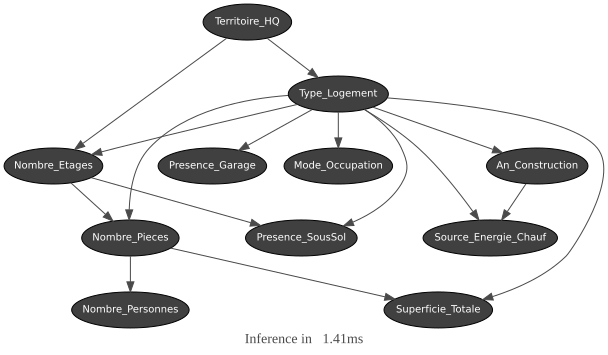

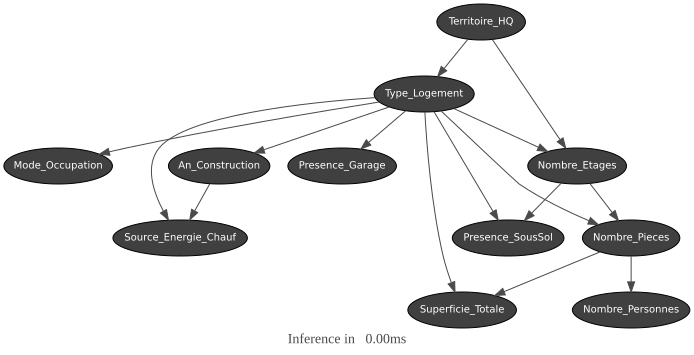

In [6]:
# Display the Bayesian Network - Avant enregistrement
gnb.showInference(InsClsEUEMr.bn, evs={}, targets={"AnConstruction"}, size="11")

# Display the Bayesian Network - Apres enregistrement
gnb.showInference(InsClsEUEMr_2.bn, evs={}, targets={"AnConstruction"}, size="11")


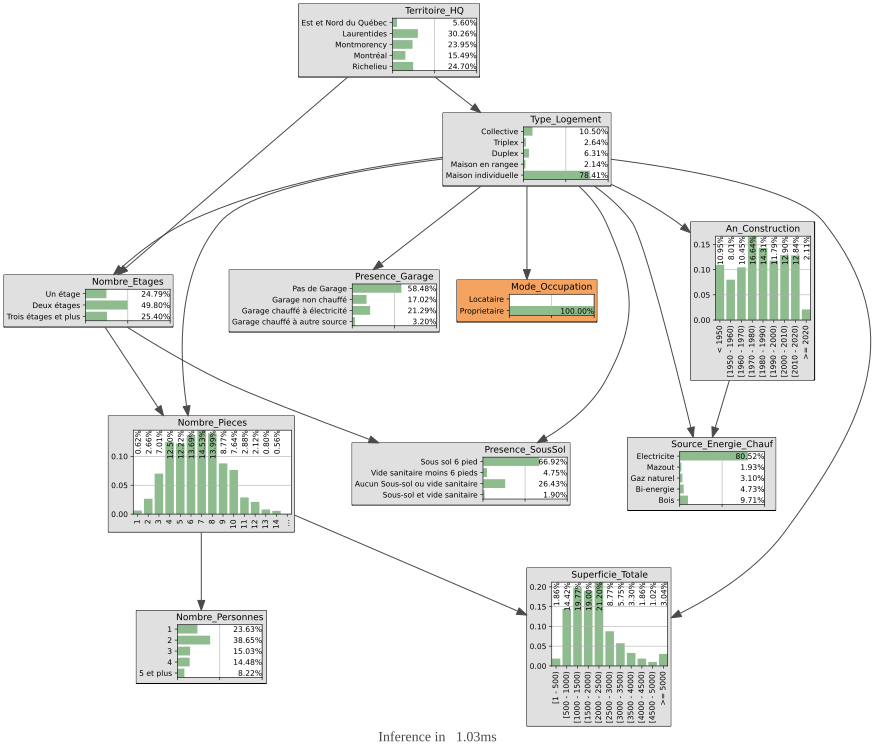

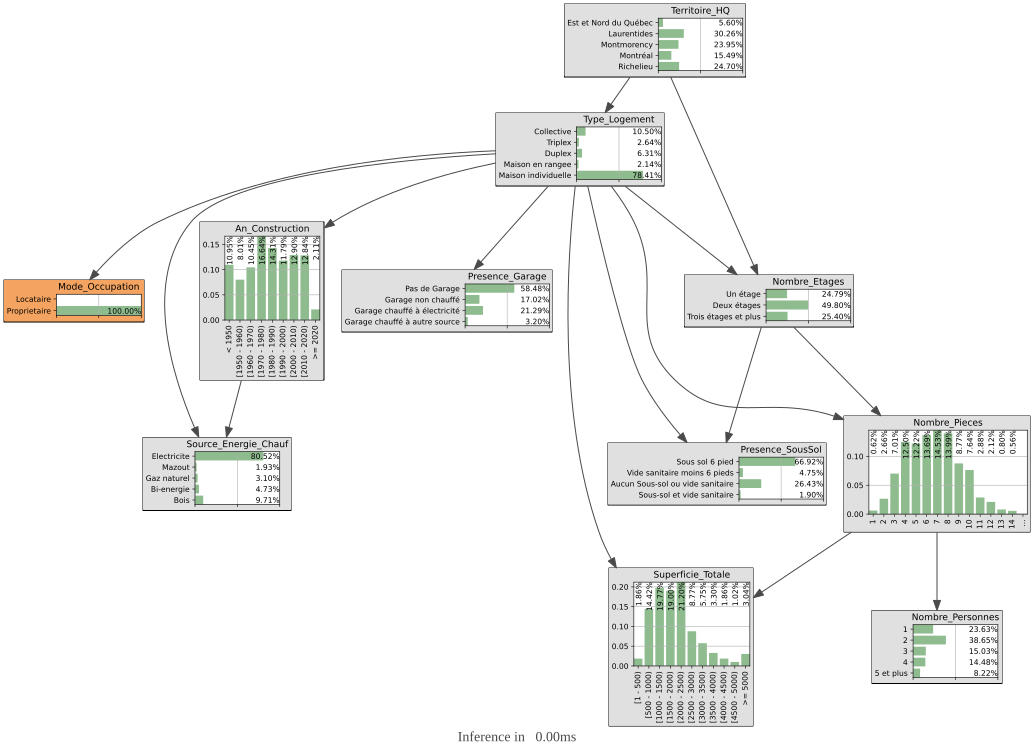

In [7]:
# Display the Bayesian Network with specific evidence - Avant enregistrement
gnb.showInference(InsClsEUEMr.bn,evs={"Mode_Occupation": "Proprietaire"},size = '30')

# Display the Bayesian Network with specific evidence - Apres enregistrement
gnb.showInference(InsClsEUEMr_2.bn,evs={"Mode_Occupation": "Proprietaire"},size = '30')


In [8]:
Nombre_de_Samples = 3
Evidence = {"Mode_Occupation": "Proprietaire"}

# Fait un échantillonage - Avant enregistrement
df1 = InsClsEUEMr.do_Sampling(Nombre_de_Samples, evs = Evidence)

# Fait un échantillonage - Apres enregistrement
df2 = InsClsEUEMr_2.do_Sampling(Nombre_de_Samples, evs = Evidence)

# Affiche les échantillons - Avant enregistrement
df1, df2

(  Territoire_HQ        Type_Logement               Presence_Garage  \
 0   Montmorency  Maison individuelle                 Pas de Garage   
 1      Montréal  Maison individuelle                 Pas de Garage   
 2   Laurentides  Maison individuelle  Garage chauffé à électricité   
 
   An_Construction Source_Energie_Chauf Mode_Occupation         Nombre_Etages  \
 0          < 1950          Electricite    Proprietaire           Deux étages   
 1   [2000 - 2010)          Electricite    Proprietaire  Trois étages et plus   
 2   [2010 - 2020)          Electricite    Proprietaire              Un étage   
 
   Presence_SousSol Nombre_Pieces Superficie_Totale Nombre_Personnes  
 0  Sous sol 6 pied             6     [2000 - 2500)                2  
 1  Sous sol 6 pied             6     [1500 - 2000)                2  
 2  Sous sol 6 pied             7           >= 5000                2  ,
   Territoire_HQ        Type_Logement Mode_Occupation     Presence_Garage  \
 0   Laurentides  Maison i

In [9]:
#proportion de valeur
# Fait un échantillonage - Apres enregistrement
df3 = InsClsEUEMr_2.do_Sampling(1000, evs = {})

for col in df2.columns:
    print(col + ":" + str(df3[col].value_counts()/ len(df3)))


Territoire_HQ:Territoire_HQ
Laurentides              0.266
Richelieu                0.237
Montréal                 0.235
Montmorency              0.217
Est et Nord du Québec    0.045
Name: count, dtype: float64
Type_Logement:Type_Logement
Maison individuelle    0.548
Collective             0.273
Duplex                 0.101
Triplex                0.054
Maison en rangee       0.024
Name: count, dtype: float64
Mode_Occupation:Mode_Occupation
Proprietaire    0.646
Locataire       0.354
Name: count, dtype: float64
Presence_Garage:Presence_Garage
Pas de Garage                    0.708
Garage chauffé à électricité     0.151
Garage non chauffé               0.116
Garage chauffé à autre source    0.025
Name: count, dtype: float64
Nombre_Etages:Nombre_Etages
Deux étages             0.412
Un étage                0.408
Trois étages et plus    0.180
Name: count, dtype: float64
Presence_SousSol:Presence_SousSol
Aucun Sous-sol ou vide sanitaire    0.478
Sous sol 6 pied                     0.476
Vide